# Step-by-step: propagating a segmentation mask across EM slices with SAM2

This notebook demonstrates, end to end, how the vendored [SAM2](https://github.com/facebookresearch/sam2)
copy in this repository is used for vascular-structure instance segmentation of
volume electron microscopy (vEM) images of human liver tissue (see the main
[README](../../README.md) and `sam2maskpropagator.py`).

Rather than segmenting a single 2D image, SAM2's video predictor treats a short stack
of serial-section EM images as "video frames" and propagates a mask, initialised from
a single box prompt on one frame, across the rest of the stack — substantially more
efficient than segmenting every slice independently.

This notebook walks through:

1. Loading a short stack of example EM slices (real serial sections from the human
   liver vEM dataset used in the manuscript, cropped around a sinusoid lumen).
2. Building the SAM2 video predictor from a checkpoint.
3. Prompting the sinusoid lumen with a single bounding box on one frame.
4. Propagating that mask forward and backward across the rest of the stack.
5. Visualising the propagated masks alongside a reference segmentation available
   for this example region.

**Note on checkpoints:** for speed, this notebook uses the small "tiny" SAM2
checkpoint on CPU. For production use, the main README recommends the larger
`sam2_hiera_large` checkpoint on a GPU (`--checkpoint SAM2/sam2_hiera_large.pt`,
`--model_cfg sam2_hiera_l.yaml`); see `download_ckpts.sh`. Swap `MODEL_CFG` /
`CHECKPOINT` / `DEVICE` below accordingly.

In [1]:
import os
import sys
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Make the vendored `sam2` package (one level up from this notebook) importable
# without installing it.
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Silence environment-specific warnings that are harmless here (e.g. a CUDA
# probe warning on CPU-only machines, and SAM2's optional compiled-extension
# warning; see https://github.com/facebookresearch/segment-anything-2/blob/main/INSTALL.md).
warnings.filterwarnings("ignore", category=UserWarning)

import torch
from sam2.build_sam import build_sam2_video_predictor

print("SAM2 import OK. Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

SAM2 import OK. Torch: 2.6.0 | CUDA available: False


## 1. Example EM slice stack

`notebooks/em_example_video/` contains 8 consecutive serial-section EM slices, spatially
cropped around a sinusoid lumen so it is clearly visible across the whole stack. This is
exactly the kind of directory `sam2maskpropagator.py`'s `--video_dir` argument expects:
one image file per slice, sortable into z-order.

Found 8 frames: ['human_100_0000.png', 'human_101_0000.png', 'human_102_0000.png', 'human_103_0000.png', 'human_104_0000.png', 'human_105_0000.png', 'human_106_0000.png', 'human_107_0000.png']


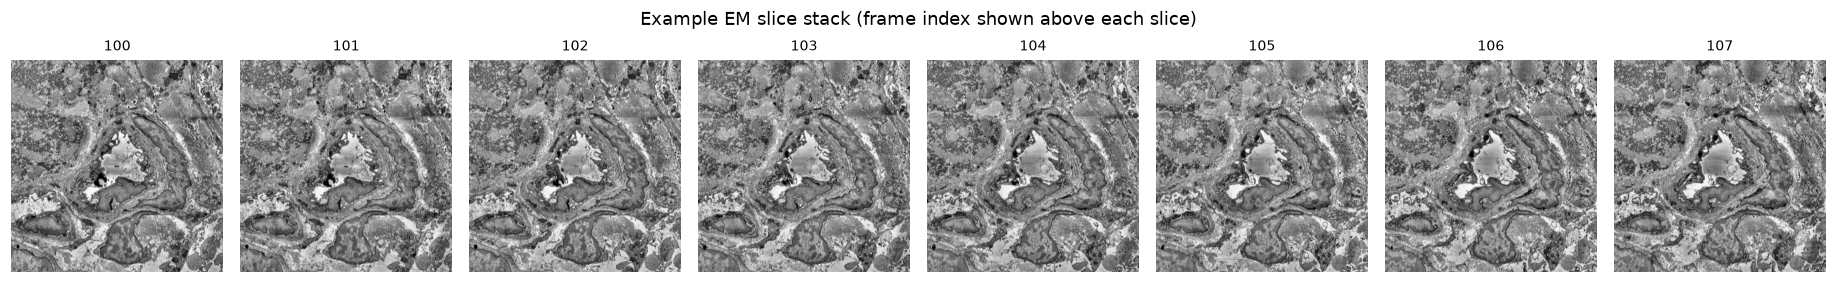

In [2]:
VIDEO_DIR = "em_example_video"

frame_names = sorted(
    (f for f in os.listdir(VIDEO_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))),
    key=lambda p: int(p.split("_")[1][:3]),
)
print(f"Found {len(frame_names)} frames: {frame_names}")

fig, axes = plt.subplots(1, len(frame_names), figsize=(2.1 * len(frame_names), 2.6))
for ax, fname in zip(axes, frame_names):
    ax.imshow(np.array(Image.open(os.path.join(VIDEO_DIR, fname))), cmap="gray")
    ax.set_title(fname.split("_")[1], fontsize=9)
    ax.axis("off")
fig.suptitle("Example EM slice stack (frame index shown above each slice)")
plt.tight_layout()
plt.show()

## 2. Build the SAM2 video predictor and load the frames

`build_sam2_video_predictor` reads a Hydra model config (`MODEL_CFG`) and a checkpoint
file (`CHECKPOINT`) and returns a predictor whose `init_state` loads and normalises all
frames in `video_dir` up front. No GPU is required for this demo (`DEVICE = "cpu"`),
but propagation is much faster with a GPU and the larger checkpoint.

In [3]:
# Small, fast checkpoint for this CPU demo. For production runs, use
# MODEL_CFG="sam2_hiera_l.yaml", CHECKPOINT="../sam2_hiera_large.pt", DEVICE="cuda"
# (download with `cd .. && bash download_ckpts.sh`, see main README).
MODEL_CFG = "sam2_hiera_t.yaml"
CHECKPOINT = "../sam2_hiera_tiny.pt"
DEVICE = "cpu"

predictor = build_sam2_video_predictor(MODEL_CFG, CHECKPOINT, device=DEVICE)

t0 = time.time()
inference_state = predictor.init_state(video_path=VIDEO_DIR)
print(f"Loaded {len(frame_names)} frames in {time.time() - t0:.1f}s")

Loaded 8 frames in 7.8s


frame loading (JPEG): 100%|##########| 8/8 [00:00<00:00, 23.25it/s]


## 3. Prompt: a single bounding box on the first frame

We draw one bounding box, on the first frame of the stack, around the sinusoid lumen
visible in the crop. `add_new_points_or_box` immediately returns a mask for that frame
so the prompt can be sanity-checked before propagating it across the rest of the
stack. A box prompt is used rather than a point click because a click can land
ambiguously between the open lumen and the surrounding endothelial lining, whereas a
box reliably selects the whole lumen. This mirrors how `SAM2VideoMaskPropagator`
prompts large vascular lumens in `sam2maskpropagator.py` (the same propagated masks
feed the sinusoid/LSEC morphometric analysis described in the manuscript).

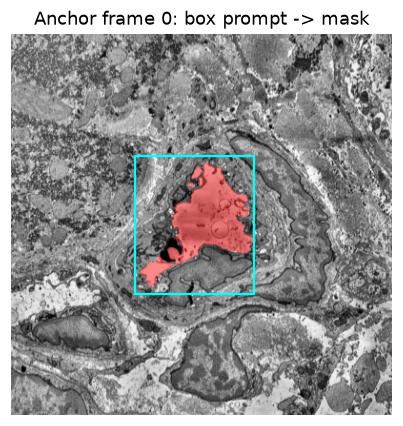

In [4]:
ANCHOR_FRAME_IDX = 0  # first frame of the stack
OBJ_ID = 1
BOX_XYXY = np.array([129.2, 127.6, 254.8, 272.4], dtype=np.float32)  # [x1, y1, x2, y2]

predictor.reset_state(inference_state)
_, _, anchor_masks = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ANCHOR_FRAME_IDX,
    obj_id=OBJ_ID,
    box=BOX_XYXY,
)
anchor_mask = (anchor_masks[0, 0] > 0.0).cpu().numpy()

anchor_img = np.array(Image.open(os.path.join(VIDEO_DIR, frame_names[ANCHOR_FRAME_IDX])))
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(anchor_img, cmap="gray")
rgba = np.zeros((*anchor_mask.shape, 4))
rgba[anchor_mask] = (1, 0, 0, 0.45)
ax.imshow(rgba)
rect = plt.Rectangle(
    (BOX_XYXY[0], BOX_XYXY[1]), BOX_XYXY[2] - BOX_XYXY[0], BOX_XYXY[3] - BOX_XYXY[1],
    linewidth=1.5, edgecolor="cyan", facecolor="none",
)
ax.add_patch(rect)
ax.set_title(f"Anchor frame {ANCHOR_FRAME_IDX}: box prompt -> mask")
ax.axis("off")
plt.show()

## 4. Propagate forward across the stack

`propagate_in_video` carries the object's memory features from the anchor frame
forward to every subsequent frame, yielding one mask per frame without any further
clicks. Because the box was prompted on the very first frame, a single forward pass
covers the whole stack. `SAM2VideoMaskPropagator` uses this same forward-only
propagation call in `sam2maskpropagator.py`, and a bidirectional variant
(propagating both forward and backward from a single anchor frame, via
`reverse=True`) for structures prompted on a middle frame of a longer stack.

In [5]:
video_masks = {ANCHOR_FRAME_IDX: anchor_mask}

t0 = time.time()
for frame_idx, _, logits in predictor.propagate_in_video(inference_state):
    video_masks[frame_idx] = (logits[0, 0] > 0.0).cpu().numpy()

print(f"Propagated across {len(video_masks)} frames in {time.time() - t0:.1f}s")

Propagated across 8 frames in 40.7s


propagate in video: 100%|##########| 8/8 [00:40<00:00,  5.05s/it]


## 5. Visualise the propagated segmentation

The propagated mask (red) is overlaid on each raw EM slice, showing that a single box
prompt on the first frame is enough to track the sinusoid lumen consistently across
the whole stack.

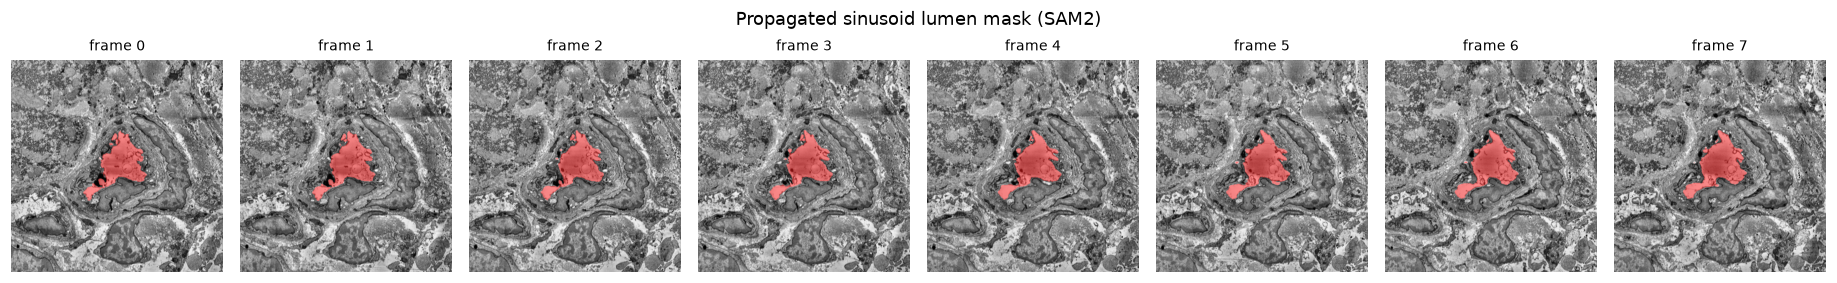

In [6]:
n = len(frame_names)
fig, axes = plt.subplots(1, n, figsize=(2.1 * n, 2.6))

for i, fname in enumerate(frame_names):
    img = np.array(Image.open(os.path.join(VIDEO_DIR, fname)))
    pred = video_masks[i]

    axes[i].imshow(img, cmap="gray")
    rgba = np.zeros((*pred.shape, 4))
    rgba[pred] = (1, 0, 0, 0.45)
    axes[i].imshow(rgba)
    axes[i].set_title(f"frame {i}", fontsize=9)
    axes[i].axis("off")

fig.suptitle("Propagated sinusoid lumen mask (SAM2)")
plt.tight_layout()
plt.show()

## 6. Scaling up: using `sam2maskpropagator.py` for production runs

For a full serial-section volume with many structures/objects, use the repository's
`SAM2VideoMaskPropagator` (in `../../sam2maskpropagator.py`) instead of calling the
predictor directly, either from Python or via the CLI. The `sinusoidal_capillary`
label type below is what was used to propagate the sinusoid lumen segmented above
across the full volume:

```bash
python ../../sam2maskpropagator.py \
  --label_type sinusoidal_capillary \
  --checkpoint SAM2/sam2_hiera_large.pt \
  --model_cfg sam2_hiera_l.yaml \
  --video_dir /path/to/full_em_slice_stack \
  --output_dir /path/to/output_masks \
  --mode video_only \
  --box_prompts_json /path/to/box_prompts.json
```

This handles saving per-frame instance-label masks, multi-object propagation, and
(for hepatocytes) SWC-guided automatic prompt generation &mdash; see the main README's
"Vascular and Cellular Level Segmentation" section and the module docstring in
`sam2maskpropagator.py` for the full set of options, including the propagation
strategy (bidirectional vs. forward-only) used for each `--label_type`.